# ⏩ Incremental / CDC Loader

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/incremental-loader/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/incremental-loader/demo.ipynb)

**Pain point:** *"Full reloads take hours every night."*

Watermark-based extraction + key upsert + soft-delete handling — load only what changed, and watch the work drop from 100% to ~11% per cycle.

**What this notebook covers:**
1. The three pieces — watermark store, incremental extract, upsert merge
2. Five simulated load days against a mutating source table
3. Correctness checks — keys unique, deletes applied
4. The savings chart: full reload vs incremental
5. Try your own change rates


## Step 1 — The three pieces

- **`WatermarkStore`** — a tiny JSON file remembering the max `updated_at` seen per table. The next run asks only for rows *after* it.
- **`extract_increment`** — `source[source.updated_at > watermark]`. First run (no watermark) = full load; every run after = just the delta.
- **`upsert`** — merge the delta into the target by key: update matches, insert new keys, and honor CDC tombstones (`deleted=True` rows remove their key from the target).

The simulator mutates a fake customer table each "day" (inserts, in-place updates, soft deletes) so the loop can be tested end-to-end without a database — the same logic ports to SQL `MERGE` unchanged.


In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import pandas as pd


@dataclass
class LoadStats:
    cycle: int
    source_rows: int
    extracted: int
    inserted: int
    updated: int
    deleted: int
    watermark: str

    @property
    def scanned_pct(self) -> float:
        return round(100 * self.extracted / self.source_rows, 1) if self.source_rows else 0.0


class WatermarkStore:
    """Persists the high-watermark per table so each run picks up where the last one stopped."""

    def __init__(self, path: str = "watermarks.json") -> None:
        self.path = Path(path)
        self._data: Dict[str, str] = json.loads(self.path.read_text()) if self.path.exists() else {}

    def get(self, table: str) -> Optional[str]:
        return self._data.get(table)

    def set(self, table: str, value: str) -> None:
        self._data[table] = value
        self.path.write_text(json.dumps(self._data, indent=2))


def extract_increment(source: pd.DataFrame, watermark_col: str, last_watermark: Optional[str]) -> pd.DataFrame:
    """Rows changed since the last watermark — the whole point: never rescan the full table."""
    if last_watermark is None:
        return source.copy()
    return source[source[watermark_col] > last_watermark].copy()


def upsert(target: pd.DataFrame, increment: pd.DataFrame, key: str,
           soft_delete_col: Optional[str] = None) -> Tuple[pd.DataFrame, Dict[str, int]]:
    """Merge an increment into the target by key: update matches, insert new, apply tombstones."""
    counts = {"inserted": 0, "updated": 0, "deleted": 0}
    if increment.empty:
        return target, counts

    inc = increment.copy()
    if soft_delete_col and soft_delete_col in inc.columns:
        tombstones = inc[inc[soft_delete_col].fillna(False).astype(bool)]
        counts["deleted"] = int(target[key].isin(tombstones[key]).sum())
        target = target[~target[key].isin(tombstones[key])]
        inc = inc[~inc[soft_delete_col].fillna(False).astype(bool)]

    existing = set(target[key])
    counts["updated"] = int(inc[key].isin(existing).sum())
    counts["inserted"] = len(inc) - counts["updated"]

    merged = pd.concat([target[~target[key].isin(inc[key])], inc], ignore_index=True)
    return merged.sort_values(key).reset_index(drop=True), counts


def run_incremental_load(source: pd.DataFrame, target: pd.DataFrame, key: str, watermark_col: str,
                         store: WatermarkStore, table: str = "default", cycle: int = 1,
                         soft_delete_col: Optional[str] = None) -> Tuple[pd.DataFrame, LoadStats]:
    """One load cycle: read watermark → extract increment → upsert → advance watermark."""
    last = store.get(table)
    increment = extract_increment(source, watermark_col, last)
    merged, counts = upsert(target, increment, key, soft_delete_col)
    new_watermark = str(source[watermark_col].max()) if len(source) else (last or "")
    store.set(table, new_watermark)
    stats = LoadStats(cycle=cycle, source_rows=len(source), extracted=len(increment),
                      watermark=new_watermark, **counts)
    return merged, stats


def simulate_source_day(source: pd.DataFrame, day: str, n_inserts: int, n_updates: int,
                        n_deletes: int, key: str = "id", seed: int = 42) -> pd.DataFrame:
    """Mutate a fake source table for one 'day': inserts, in-place updates, soft deletes."""
    rng = pd.Series(range(len(source))).sample(frac=1, random_state=seed).index
    df = source.copy()
    ts = f"{day} 09:00:00"

    live = df[~df["deleted"].fillna(False).astype(bool)]
    upd_keys = live[key].sample(min(n_updates, len(live)), random_state=seed)
    df.loc[df[key].isin(upd_keys), ["amount", "updated_at"]] = [
        round(100 + 900 * (seed % 7) / 7, 2), ts]

    remaining = df[~df[key].isin(upd_keys) & ~df["deleted"].fillna(False).astype(bool)]
    del_keys = remaining[key].sample(min(n_deletes, len(remaining)), random_state=seed + 1)
    df.loc[df[key].isin(del_keys), ["deleted", "updated_at"]] = [True, ts]

    start_id = int(df[key].str.replace("cust-", "").astype(int).max()) + 1
    new = pd.DataFrame({
        key: [f"cust-{start_id + i:04d}" for i in range(n_inserts)],
        "amount": [round(50.0 + 13.7 * i, 2) for i in range(n_inserts)],
        "updated_at": ts,
        "deleted": False,
    })
    _ = rng
    return pd.concat([df, new], ignore_index=True)


def make_initial_source(n: int = 500, day: str = "2026-07-01") -> pd.DataFrame:
    return pd.DataFrame({
        "id": [f"cust-{i:04d}" for i in range(1, n + 1)],
        "amount": [round(20 + (i * 37.3) % 480, 2) for i in range(1, n + 1)],
        "updated_at": f"{day} 08:00:00",
        "deleted": False,
    })


## Step 2 — Simulate five load days

Day 1 seeds 500 customers. Each following day: 40 inserts, 25 updates, 5 soft deletes. One `run_incremental_load` call per day.

In [2]:
import tempfile
from pathlib import Path

store = WatermarkStore(str(Path(tempfile.mkdtemp()) / "wm.json"))
source = make_initial_source(500)
target = source.iloc[0:0].copy()

history = []
for d in range(5):
    day = f"2026-07-{d + 1:02d}"
    if d > 0:
        source = simulate_source_day(source, day, n_inserts=40, n_updates=25, n_deletes=5, seed=42 + d)
    target, stats = run_incremental_load(source, target, key="id", watermark_col="updated_at",
                                         store=store, table="customers", cycle=d + 1,
                                         soft_delete_col="deleted")
    history.append(stats)
    print(f"cycle {stats.cycle}: source={stats.source_rows:4d}  extracted={stats.extracted:4d} "
          f"({stats.scanned_pct:5.1f}% scanned)  +{stats.inserted} ~{stats.updated} -{stats.deleted}  "
          f"watermark={stats.watermark}")

cycle 1: source= 500  extracted= 500 (100.0% scanned)  +500 ~0 -0  watermark=2026-07-01 08:00:00
cycle 2: source= 540  extracted=  70 ( 13.0% scanned)  +40 ~25 -5  watermark=2026-07-02 09:00:00
cycle 3: source= 580  extracted=  70 ( 12.1% scanned)  +40 ~25 -5  watermark=2026-07-03 09:00:00
cycle 4: source= 620  extracted=  70 ( 11.3% scanned)  +40 ~25 -5  watermark=2026-07-04 09:00:00
cycle 5: source= 660  extracted=  70 ( 10.6% scanned)  +40 ~25 -5  watermark=2026-07-05 09:00:00


## Step 3 — Correctness checks

An incremental loader is only useful if the target ends up identical to what a full reload would produce.

In [3]:
live_target = target[~target["deleted"].fillna(False).astype(bool)]
live_source = source[~source["deleted"].fillna(False).astype(bool)]

assert live_target["id"].is_unique, "duplicate keys after upsert!"
assert len(live_target) == len(live_source), "row count drift vs source!"
merged_check = live_target.merge(live_source, on="id", suffixes=("_t", "_s"))
assert (merged_check["amount_t"] == merged_check["amount_s"]).all(), "stale values!"
print(f"✅ target matches source: {len(live_target)} live rows, keys unique, values current")

✅ target matches source: 640 live rows, keys unique, values current


## Step 4 — The savings chart

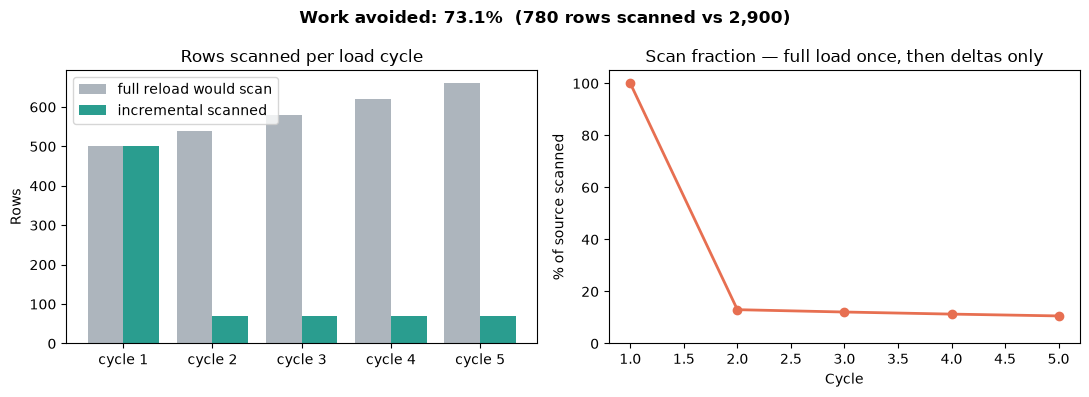

In [4]:
import matplotlib.pyplot as plt
import numpy as np

cycles = [s.cycle for s in history]
full = [s.source_rows for s in history]
inc = [s.extracted for s in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(cycles))
ax1.bar(x - 0.2, full, 0.4, label="full reload would scan", color="#adb5bd")
ax1.bar(x + 0.2, inc, 0.4, label="incremental scanned", color="#2a9d8f")
ax1.set_xticks(x)
ax1.set_xticklabels([f"cycle {c}" for c in cycles])
ax1.set_ylabel("Rows")
ax1.set_title("Rows scanned per load cycle")
ax1.legend()

pct = [s.scanned_pct for s in history]
ax2.plot(cycles, pct, marker="o", color="#e76f51", linewidth=2)
ax2.set_ylabel("% of source scanned")
ax2.set_xlabel("Cycle")
ax2.set_title("Scan fraction — full load once, then deltas only")
ax2.set_ylim(0, 105)

total_full, total_inc = sum(full), sum(inc)
fig.suptitle(f"Work avoided: {100 * (1 - total_inc / total_full):.1f}%  "
             f"({total_inc:,} rows scanned vs {total_full:,})", fontweight="bold")
fig.tight_layout()
fig.savefig("incremental_savings.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Cycle | Source rows | Scanned | % |
|---|---|---|---|
| 1 (initial) | 500 | 500 | 100% |
| 2-5 (steady state) | 540-660 | 70 each | ~11-13% |

Steady state scans ~11% of the source — and that fraction *shrinks* as the table grows, because the daily delta stays constant while the full table doesn't. The pattern (watermark → delta → upsert → advance watermark) is exactly what SQL `MERGE`, Airbyte incremental syncs, and Delta Lake CDF implement at scale.


## Try your own

Change the mutation mix — heavy updates, no deletes, bursty inserts:

In [5]:
# store2 = WatermarkStore(str(Path(tempfile.mkdtemp()) / "wm2.json"))
# src = make_initial_source(2000)
# tgt = src.iloc[0:0].copy()
# for d in range(7):
#     day = f"2026-08-{d + 1:02d}"
#     if d > 0:
#         src = simulate_source_day(src, day, n_inserts=10, n_updates=300, n_deletes=0, seed=d)
#     tgt, s = run_incremental_load(src, tgt, "id", "updated_at", store2, "orders", d + 1, "deleted")
#     print(f"cycle {s.cycle}: scanned {s.scanned_pct}%")

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
